Import necessary libraries, ensure tensorflow installed and system configured properly. 

In [125]:
%matplotlib inline
import random
import tensorflow as tf
from d2l import tensorflow as d2l




Dataset generation: synthetic dataset is created with given weight and bias parameters

In [126]:
def synthetic_data(w, b, num_examples):  #@save
    """Generate y = Xw + b + noise."""
    X = tf.zeros((num_examples, w.shape[0]))
    X += tf.random.normal(shape=X.shape)
    y = tf.matmul(X, tf.reshape(w, (-1, 1))) + b
    y += tf.random.normal(shape=y.shape, stddev=0.01)
    y = tf.reshape(y, (-1, 1))
    return X, y

In [127]:
true_w = tf.constant([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [128]:
print('features:', features[0],'\nlabel:', labels[0])

features: tf.Tensor([1.3728242 1.4564803], shape=(2,), dtype=float32) 
label: tf.Tensor([1.9783403], shape=(1,), dtype=float32)


Generate a scatterplot showing distrubtion of values 

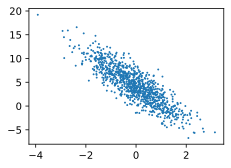

In [129]:
d2l.set_figsize()
# The semicolon is for displaying the plot only
d2l.plt.scatter(features[:, (1)].numpy(), labels.numpy(), 1);

define a minibatch iteration algorithm for training:

In [130]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # The examples are read at random, in no particular order
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        j = tf.constant(indices[i: min(i + batch_size, num_examples)])
        yield tf.gather(features, j), tf.gather(labels, j)

naive approach to minibatch iteration, requires entire dataset to be in memory, in practice the deep learning model has highly efficient implementations of this procedure.

In [131]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tf.Tensor(
[[ 1.4446133   0.03521311]
 [ 1.7715415  -1.0601804 ]
 [ 1.3118367  -0.6469748 ]
 [ 0.38063595 -0.8994348 ]
 [-0.22168827  1.0347961 ]
 [-1.1122376  -0.07959127]
 [-0.5767163   0.28131488]
 [-1.4883844  -1.5719597 ]
 [ 0.3284759   0.41105148]
 [-0.85946953 -0.36960182]], shape=(10, 2), dtype=float32) 
 tf.Tensor(
[[ 6.9588675 ]
 [11.358328  ]
 [ 9.028091  ]
 [ 8.023211  ]
 [ 0.23299183]
 [ 2.2385695 ]
 [ 2.077953  ]
 [ 6.5674014 ]
 [ 3.4403493 ]
 [ 3.7277024 ]], shape=(10, 1), dtype=float32)


initialize model parameters:

In [132]:
w = tf.Variable(tf.random.normal(shape=(2, 1), mean=0, stddev=0.01),
                trainable=True)
b = tf.Variable(tf.zeros(1), trainable=True)

the linear regression model:

In [133]:
def linreg(X, w, b):  #@save
    """The linear regression model."""
    return tf.matmul(X, w) + b

the loss function:

In [134]:
def squared_loss(y_hat, y):  #@save
    """Squared loss."""
    return (y_hat - tf.reshape(y, y_hat.shape)) ** 2 / 2

optimization algorithm to minimize parameter loss:

In [135]:
def sgd(params, grads, lr, batch_size):  #@save
    """Minibatch stochastic gradient descent."""
    for param, grad in zip(params, grads):
        param.assign_sub(lr*grad/batch_size)


training loop:

In [136]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        with tf.GradientTape() as g:
            l = loss(net(X, w, b), y)  # Minibatch loss in `X` and `y`
        # Compute gradient on l with respect to [`w`, `b`]
        dw, db = g.gradient(l, [w, b])
        # Update parameters using their gradient
        sgd([w, b], [dw, db], lr, batch_size)
    train_l = loss(net(features, w, b), labels)
    print(f'epoch {epoch + 1}, loss {float(tf.reduce_mean(train_l)):f}')

epoch 1, loss 0.032536
epoch 2, loss 0.000121
epoch 3, loss 0.000049


can measure accuracy of model since the dataset is synthetic and we know true values for parameters:

In [124]:
print(f'error in estimating w: {true_w - tf.reshape(w, true_w.shape)}')
print(f'error in estimating b: {true_b - b}')

error in estimating w: [0.00061357 0.00055003]
error in estimating b: [0.00053835]
